This code defines a SimpleTokenizer class, which is a basic implementation of a tokenizer, a crucial component in natural language processing (NLP) models like BERT.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Defines a simple tokenizer for converting text into numerical representations (token IDs).
# This tokenizer is designed to be a basic component for a BERT-like model.
class SimpleTokenizer:
    def __init__(self, corpus, max_len=10):
        """
        Initializes the SimpleTokenizer.

        Args:
            corpus (list of str): A list of sentences to build the vocabulary from.
            max_len (int): The maximum sequence length for tokenized outputs.
                           Sequences longer than this will be truncated, and shorter ones padded.
        """
        self.max_len = max_len

        # Initial vocabulary setup:
        # 1. Join all sentences in the corpus into a single string.
        # 2. Split the string into words.
        # 3. Use a set to get unique words.
        # 4. Sort the unique words to ensure consistent vocabulary order.
        words = sorted(list(set(" ".join(corpus).split())))
        # Add special tokens required by BERT-like models to the vocabulary.
        # [PAD]: Padding token, used to make sequences of equal length.
        # [MASK]: Mask token, used for Masked Language Modeling (MLM) pre-training.
        # [CLS]: Classifier token, typically prepended to the input for classification tasks.
        # [SEP]: Separator token, used to separate two sentences or parts of a sentence.
        self.words = ["[PAD]", "[MASK]", "[CLS]", "[SEP]"] + words
        # Create a mapping from word to its unique integer ID.
        self.word2idx = {word: i for i, word in enumerate(self.words)}
        # Create a reverse mapping from integer ID back to the word.
        self.idx2word = {i: word for i, word in enumerate(self.words)}
        # Store the total size of the vocabulary.
        self.vocab_size = len(self.words)

    def encode(self, text):
        """
        Encodes a given text string into a list of token IDs.

        Args:
            text (str): The input text to be tokenized and encoded.

        Returns:
            list: A list of integer token IDs, padded or truncated to `self.max_len`.
        """
        # Split the input text into individual tokens (words).
        tokens = text.split()
        # Convert each token into its corresponding integer ID using the word2idx mapping.
        # If a word is not in the vocabulary, this will raise a KeyError.
        ids = [self.word2idx[w] for w in tokens]

        # Padding and Truncation Logic:
        # If the sequence of IDs is shorter than max_len, pad it with [PAD] tokens.
        if len(ids) < self.max_len:
            ids += [self.word2idx["[PAD]"]] * (self.max_len - len(ids))
        # If the sequence of IDs is longer than max_len, truncate it.
        else:
            ids = ids[:self.max_len]
        return ids

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        # Ensure d_model is divisible by num_heads for proper splitting
        assert d_model % num_heads == 0

        # d_k is the dimension of the key, query, and value vectors for each head
        self.d_k = d_model // num_heads

        # Linear layers for Q (Query), K (Key), V (Value) projections
        # These project the input into a higher-dimensional space before splitting into heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        # Final linear layer to project the concatenated output back to d_model dimension
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        # q, k, v typically have shape: [batch_size, seq_len, d_model]
        batch_size = q.size(0)

        # 1. Linear projections and split into multiple heads
        # Apply linear projections (w_q, w_k, w_v) to the input tensors.
        # Reshape to [batch_size, seq_len, num_heads, d_k] and then transpose to
        # [batch_size, num_heads, seq_len, d_k] for parallel computation across heads.
        Q = self.w_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Scaled Dot-Product Attention (for each head simultaneously)
        # Calculate attention scores: Q * K^T / sqrt(d_k)
        # Q: [batch, heads, seq_len, d_k], K.transpose(-2, -1): [batch, heads, d_k, seq_len]
        # Result 'scores': [batch, heads, seq_len, seq_len]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask (e.g., for padding or future token prevention in decoders)
        # Masking fills positions where mask == 0 with a very small negative number (-1e9)
        # This causes them to become 0 after softmax, effectively ignoring them.
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # Apply softmax to get attention weights (probabilities) along the last dimension (key sequence length)
        attn = F.softmax(scores, dim=-1)
        # Multiply attention weights by Value vectors
        # attn: [batch, heads, seq_len, seq_len], V: [batch, heads, seq_len, d_k]
        # context: [batch, heads, seq_len, d_k]
        context = torch.matmul(attn, V)

        # 3. Concatenate heads and apply final linear projection
        # Transpose back to [batch_size, seq_len, num_heads, d_k]
        # contiguous() is needed before view() if memory is not contiguous after transpose
        # view to [batch_size, seq_len, d_model] to concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        # Apply final output linear projection (w_o)
        return self.w_o(context)

In [3]:
def create_attention_mask(input_ids, pad_token_id):
    # input_ids shape: [batch_size, seq_len]
    # mask shape: [batch_size, 1, 1, seq_len]
    # We add extra dimensions so it broadcasts across all heads and all query positions
    mask = (input_ids != pad_token_id).unsqueeze(1).unsqueeze(2)
    return mask.int()

In [4]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff) # First linear transformation, expanding the dimension
        self.linear2 = nn.Linear(d_ff, d_model) # Second linear transformation, projecting back to the original dimension
        self.activation = nn.GELU() # BERT specifically uses GELU

    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

In [5]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        # Multi-Head Self-Attention layer: processes input sequences to capture relationships between tokens.
        self.attention = MultiHeadAttention(d_model, num_heads)
        # First Layer Normalization: applied after attention and before the feed-forward network.
        self.norm1 = nn.LayerNorm(d_model)
        # Feed-Forward Network: a simple point-wise fully connected network.
        self.ff = FeedForward(d_model, d_ff)
        # Second Layer Normalization: applied after the feed-forward network.
        self.norm2 = nn.LayerNorm(d_model)
        # Dropout layer: used for regularization to prevent overfitting.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Pass mask to the MultiHeadAttention layer to ignore padding or future tokens.
        attn_out = self.attention(x, x, x, mask)
        # Add and Norm: apply dropout to attention output, then add it to the original input (residual connection),
        # and finally apply layer normalization (norm1).
        x = self.norm1(x + self.dropout(attn_out))

        # Feed-forward network processing.
        ff_out = self.ff(x)
        # Add and Norm: apply dropout to feed-forward output, add it to the output from the first Add&Norm block,
        # and apply layer normalization (norm2).
        x = self.norm2(x + self.dropout(ff_out))
        return x

In [6]:
class BERT(nn.Module):
    # This class implements a simplified BERT (Bidirectional Encoder Representations from Transformers) model.
    # It's primarily designed for Masked Language Modeling (MLM) as a pre-training objective.
    def __init__(self, vocab_size, d_model=256, n_layers=4, num_heads=8, max_len=128):
        super().__init__() # Initialize the base nn.Module class
        self.token_emb = nn.Embedding(vocab_size, d_model) # Token embeddings: converts token IDs to dense vectors.
        self.pos_emb = nn.Embedding(max_len, d_model) # Learned positional embeddings: adds positional information to tokens.

        # Stack of Transformer Encoder Blocks
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_model * 4) for _ in range(n_layers)
        ])

        # Head for Masked Language Modeling (MLM): predicts the masked token's vocabulary ID.
        self.mlm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        # x: input tensor of token IDs, shape [batch_size, seq_len]
        batch_size, seq_len = x.size()
        # Generate positional indices for the input sequence
        pos = torch.arange(seq_len, device=x.device).expand(batch_size, seq_len)

        # Combine token and positional embeddings
        # This creates the initial input representation for the Transformer Encoder layers.
        x = self.token_emb(x) + self.pos_emb(pos)

        # Pass the combined embeddings through each Transformer Encoder layer
        for layer in self.layers:
            # Pass the mask to each encoder block to handle padding and prevent attention to future tokens.
            x = layer(x, mask)

        # The output 'x' now contains context-rich representations. Apply the MLM head.
        return self.mlm_head(x) # Output logits for each token in the vocabulary for each position.

In [7]:
import torch.optim as optim
import random
import torch
import torch.nn as nn # Added import for nn.CrossEntropyLoss

def train_bert_padded(model, tokenizer, corpus, epochs=200, lr=1e-4,tieWeights=False):
    # This function orchestrates the training of the BERT model using Masked Language Modeling (MLM).
    optimizer = optim.Adam(model.parameters(), lr=lr) # Initialize Adam optimizer to update model weights efficiently.
    # CrossEntropyLoss is used for multi-class classification (predicting masked tokens).
    # ignore_index=-1 tells the loss function to ignore targets with value -1 (our unmasked tokens).
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    if(tieWeights):
      model.mlm_head.weight = model.token_emb.weight # Optional: Tie weights for MLM head, sometimes improves performance.
    pad_id = tokenizer.word2idx["[PAD]"] # Retrieve the token ID for padding, essential for mask creation and ignoring.

    for epoch in range(epochs):
        model.train() # Set the model to training mode, enabling dropout and batch normalization.

        # 1. Prepare Batch: Dynamically create training examples for each epoch.
        batch_input_ids = []
        batch_labels = []

        for sentence in corpus:
            ids = tokenizer.encode(sentence)
            labels = [-1] * len(ids) # Initialize labels with -1 for all tokens (ignored by loss).

            # Mask only non-padding tokens for the MLM objective.
            valid_indices = [i for i, token_id in enumerate(ids) if token_id != pad_id]
            mask_idx = random.choice(valid_indices) # Randomly select one token to mask in the sentence.

            labels[mask_idx] = ids[mask_idx] # The original token becomes the target label for prediction.
            ids[mask_idx] = tokenizer.word2idx["[MASK]"] # Replace the chosen token with the [MASK] token.

            batch_input_ids.append(ids)
            batch_labels.append(labels)

        # 2. Tensors & Mask: Convert Python lists to PyTorch tensors for model input.
        input_tensor = torch.tensor(batch_input_ids, dtype=torch.long)
        label_tensor = torch.tensor(batch_labels, dtype=torch.long)
        # Generate the attention mask to inform the model which tokens are padding and should be ignored.
        attn_mask = create_attention_mask(input_tensor, pad_id)

        # 3. Training Step: Perform forward pass, calculate loss, and update weights.
        optimizer.zero_grad() # Clear gradients from the previous training step.
        logits = model(input_tensor, attn_mask) # Forward pass: model outputs logits for each token in vocabulary.

        # Calculate the MLM loss. logits are reshaped to [batch_size*seq_len, vocab_size]
        # and labels to [batch_size*seq_len] to match CrossEntropyLoss expectation.
        loss = criterion(logits.view(-1, tokenizer.vocab_size), label_tensor.view(-1))
        loss.backward() # Backpropagation: computes gradients of loss with respect to all model parameters.
        optimizer.step() # Optimizer updates model parameters based on computed gradients.

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.6f}")


In [8]:
def generate_systematic_corpus():
    # Category 1: Fruits
    fruits = ["apple", "banana", "orange", "mango", "strawberry", "grape", "pineapple", "kiwi", "peach", "cherry"]
    fruit_templates = [
        "the {} is very sweet and tasty", "i like to eat a fresh {}",
        "the color of this {} is beautiful", "you can make juice from {}",
        "this {} was picked from the farm", "my favorite fruit is the {}",
        "a healthy snack is an {}", "the market sells {} by weight",
        "she sliced the {} into pieces", "the {} tree grows in summer"
    ]

    # Category 2: Machine Learning
    ml_terms = ["gradient", "neuron", "tensor", "epoch", "layer", "weight", "bias", "dataset", "transformer", "matrix"]
    ml_templates = [
        "the {} is a component of the model", "we need to optimize the {}",
        "a neural network has many {}", "this {} represents a mathematical vector",
        "we calculate the loss and update {}", "the {} was processed by the system",
        "every {} in the network has activation", "we use a large {} for accuracy",
        "the mathematical {} operation is fast", "training takes more than one {}"
    ]

    # Category 3: History
    history_terms = ["empire", "revolution", "monarch", "treaty", "dynasty", "colony", "knight", "artifact", "renaissance", "civilization"]
    history_templates = [
        "the rise of the {} changed the world", "a famous {} was signed after the war",
        "the ancient {} left many ruins", "historians study the {} closely",
        "the era of the {} lasted for centuries", "this {} represents a turning point",
        "power was held by the powerful {}", "the {} expanded across the continent",
        "a rare {} was found in the desert", "the cultural {} influenced modern art"
    ]

    # Category 4: Daily Life
    daily_terms = ["coffee", "umbrella", "keyboard", "wallet", "bicycle", "mirror", "calendar", "window", "blanket", "package"]
    daily_templates = [
        "I use my {} every single morning", "don't forget to grab your {} before leaving",
        "the {} is sitting on the wooden table", "I need to repair my broken {}",
        "this {} makes my life much easier", "I looked at the {} for a long time",
        "clean the {} to see more clearly", "the {} was delivered to my house",
        "it is a simple {} but very useful", "I misplaced my {} yesterday"
    ]

    corpus = []

    # Organize categories into a list of tuples for systematic iteration
    categories = [
        (fruits, fruit_templates),
        (ml_terms, ml_templates),
        (history_terms, history_templates),
        (daily_terms, daily_templates)
    ]

    # Nested loops to populate the corpus with formatted sentences
    for terms, templates in categories:
        for term in terms:
            for template in templates:
                # Insert the term into the placeholder {} of the template
                corpus.append(template.format(term))

    return corpus

# Generate the data
corpus = generate_systematic_corpus()

# Output the result to verify the size of the dataset
print(f"Total sentences generated: {len(corpus)}")

Total sentences generated: 400


In [9]:
import json
# Saving the vocabulary
# Get the unique words from your specific corpus
all_text = " ".join(corpus)
words = sorted(list(set(all_text.split())))
vocab_list = ["[PAD]", "[MASK]", "[CLS]", "[SEP]"] + words

# Save to file
with open('vocab3.json', 'w') as f:
    json.dump(vocab_list, f)

print(f"Vocab saved! Total words: {len(vocab_list)}")

Vocab saved! Total words: 180


In [10]:
tokenizer = SimpleTokenizer(corpus, max_len=15) # Set a max length
model = BERT(vocab_size=tokenizer.vocab_size, max_len=15, d_model=8, num_heads=2)

train_bert_padded(model, tokenizer, corpus,1000,lr=8e-3)

Epoch  20 | Loss: 4.618959
Epoch  40 | Loss: 4.016523
Epoch  60 | Loss: 3.368063
Epoch  80 | Loss: 2.742944
Epoch 100 | Loss: 2.334424
Epoch 120 | Loss: 1.823222
Epoch 140 | Loss: 1.530762
Epoch 160 | Loss: 1.181473
Epoch 180 | Loss: 1.177546
Epoch 200 | Loss: 0.921367
Epoch 220 | Loss: 0.860128
Epoch 240 | Loss: 0.727274
Epoch 260 | Loss: 0.718525
Epoch 280 | Loss: 0.700606
Epoch 300 | Loss: 0.694119
Epoch 320 | Loss: 0.587117
Epoch 340 | Loss: 0.571587
Epoch 360 | Loss: 0.530536
Epoch 380 | Loss: 0.575558
Epoch 400 | Loss: 0.642481
Epoch 420 | Loss: 0.491228
Epoch 440 | Loss: 0.531226
Epoch 460 | Loss: 0.427123
Epoch 480 | Loss: 0.426309
Epoch 500 | Loss: 0.418246
Epoch 520 | Loss: 0.388628
Epoch 540 | Loss: 0.449288
Epoch 560 | Loss: 0.417861
Epoch 580 | Loss: 0.383416
Epoch 600 | Loss: 0.467604
Epoch 620 | Loss: 0.504186
Epoch 640 | Loss: 0.454970
Epoch 660 | Loss: 0.455938
Epoch 680 | Loss: 0.444104
Epoch 700 | Loss: 0.395022
Epoch 720 | Loss: 0.408052
Epoch 740 | Loss: 0.372667
E

In [11]:
# Save the 'Brain' of the project
torch.save(model.state_dict(), 'minibert_emb_4categories.pth')
print("Model weights saved to minibert_emb_4categories.pth")

Model weights saved to minibert_emb_4categories.pth


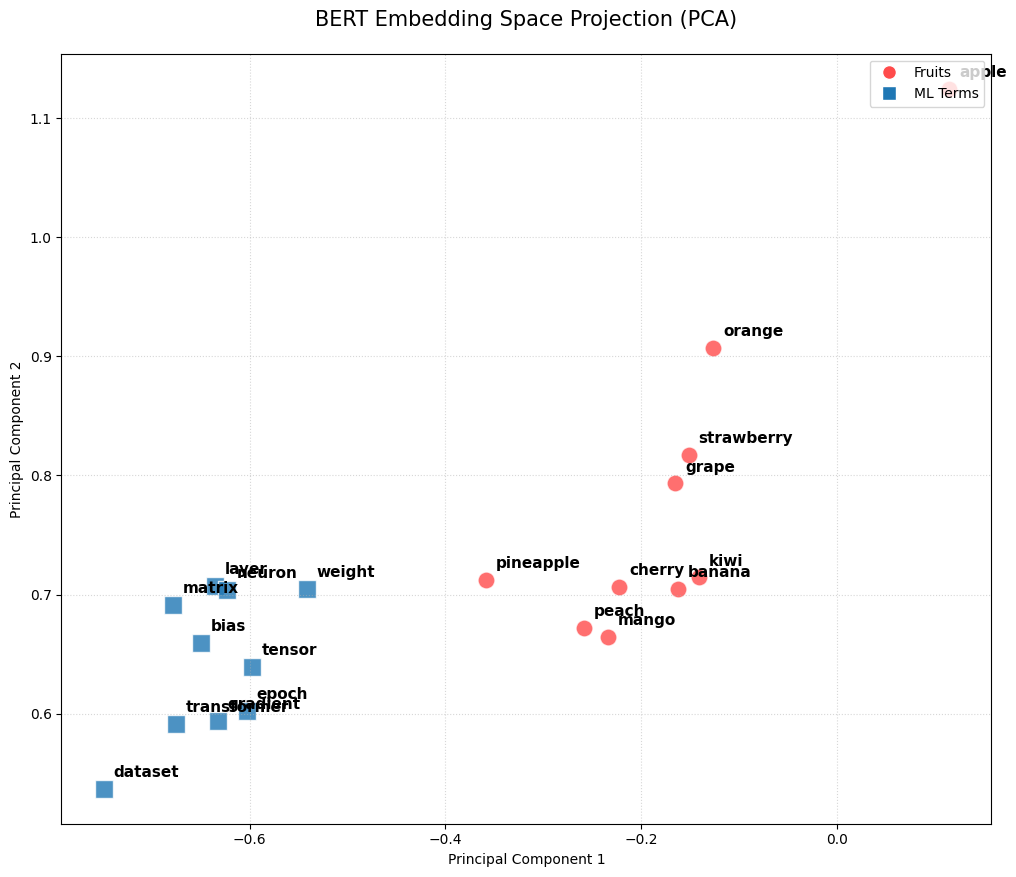

In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

def visualize_embedding_space(model, tokenizer):
    model.eval()

    # 1. Define our target words
    fruits = ["apple", "banana", "orange", "mango", "strawberry", "grape", "pineapple", "kiwi", "peach", "cherry"]
    ml_terms = ["gradient", "neuron", "tensor", "epoch", "layer", "weight", "bias", "dataset", "transformer", "matrix"]

    # 2. Get indices for all words in the vocab
    # We use all words to give PCA the full variance of the space
    all_indices = torch.arange(tokenizer.vocab_size).long()

    with torch.no_grad():
        # 3. Get the actual output of the embedding layer
        # This is the 'Embedding Space' [Vocab_Size, D_Model]
        embedded_space = model.token_emb(all_indices).cpu().numpy()

    # 4. Perform PCA to project to 2D
    pca = PCA(n_components=2)
    reduced_vectors = pca.fit_transform(embedded_space)

    # 5. Plotting
    plt.figure(figsize=(12, 10))

    for i, word in enumerate(tokenizer.words):
        if word in fruits:
            color = '#FF4B4B'  # Fruit Red
            marker = 'o'
            label_group = 'Fruits'
        elif word in ml_terms:
            color = '#1f77b4'  # ML Blue
            marker = 's'
            label_group = 'Machine Learning'
        else:
            # Optionally plot other words (like 'the', 'is', 'sweet') in gray
            color = '#cccccc'
            marker = '.'
            continue # Skip common words for a clearer cluster view

        x, y = reduced_vectors[i]
        plt.scatter(x, y, c=color, marker=marker, edgecolors='white', s=150, alpha=0.8)
        plt.text(x + 0.01, y + 0.01, word, fontsize=11, fontweight='semibold')

    plt.title("BERT Embedding Space Projection (PCA)", fontsize=15, pad=20)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle=':', alpha=0.5)

    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Fruits', markerfacecolor='#FF4B4B', markersize=10),
                       Line2D([0], [0], marker='s', color='w', label='ML Terms', markerfacecolor='#1f77b4', markersize=10)]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.show()

# Run the visualization
visualize_embedding_space(model, tokenizer)